# EDA Data Overview

**Data Mode Configuration**:
- Set `USE_SAMPLE = False` in the first cell for full dataset analysis (production)
- Set `USE_SAMPLE = True` in the first cell for quick sample testing (development)

## Distribution Analysis

**Note**: Quality assessment of processed data moved to `01_Data_Understanding/04b_processed_data_quality.ipynb`

This section focuses on exploring distributions and patterns in order/product data.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display


In [2]:
import importlib
import sys
from pathlib import Path

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Resolve project root so notebook can run from any cwd
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from instacart_quality import load_eda_base

# Load clean base tables
base_tables = load_eda_base(use_sample=USE_SAMPLE, project_root=PROJECT_ROOT)
orders = base_tables["orders"]
order_products = base_tables["order_products_prior"]

# Merge for analysis
df = order_products.merge(orders, on="order_id", how="left")

# Feature engineering: cumulative reorder per customer
df = df.sort_values(["user_id", "order_number", "add_to_cart_order"]).reset_index(drop=True)
df["cumulative_reorder_per_customer"] = df.groupby("user_id")["reordered"].cumsum()

print(f"Loaded {len(df):,} order lines from {df['order_id'].nunique():,} orders")
print(f"Serving {df['user_id'].nunique():,} unique customers")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")

Loaded 32,434,489 order lines from 3,214,874 orders
Serving 206,209 unique customers
Data mode: FULL DATASET


In [3]:
df[['user_id', 'order_number', 'product_id', 'reordered','order_hour_of_day','days_since_prior_order','cumulative_reorder_per_customer']].head(10)

,user_id,order_number,product_id,reordered,order_hour_of_day,days_since_prior_order,cumulative_reorder_per_customer
0,1,1,196,0,8,0.0,0
1,1,1,14084,0,8,0.0,0
2,1,1,12427,0,8,0.0,0
3,1,1,26088,0,8,0.0,0
4,1,1,26405,0,8,0.0,0
5,1,2,196,1,7,15.0,1
6,1,2,10258,0,7,15.0,1
7,1,2,12427,1,7,15.0,2
8,1,2,13176,0,7,15.0,2
9,1,2,26088,1,7,15.0,3


In [4]:
palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style="whitegrid")

/tmp/ipykernel_18136/1049434872.py:19: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_object_dtype(series) or is_categorical_dtype(series):


,column,status,reason,non_null,unique,missing_pct
0,add_to_cart_order,plotted,continuous,32434489,145,0.0
1,cumulative_reorder_per_customer,plotted,continuous,32434489,3276,0.0
2,days_since_prior_order,plotted,continuous,32434489,31,0.0
3,order_dow,plotted,discrete,32434489,7,0.0
4,order_hour_of_day,plotted,continuous,32434489,24,0.0
5,order_number,plotted,continuous,32434489,99,0.0
6,reordered,plotted,binary,32434489,2,0.0
7,eval_set,skipped,constant or empty column,32434489,1,0.0
8,order_id,skipped,identifier field,32434489,3214874,0.0
9,product_id,skipped,identifier field,32434489,49677,0.0


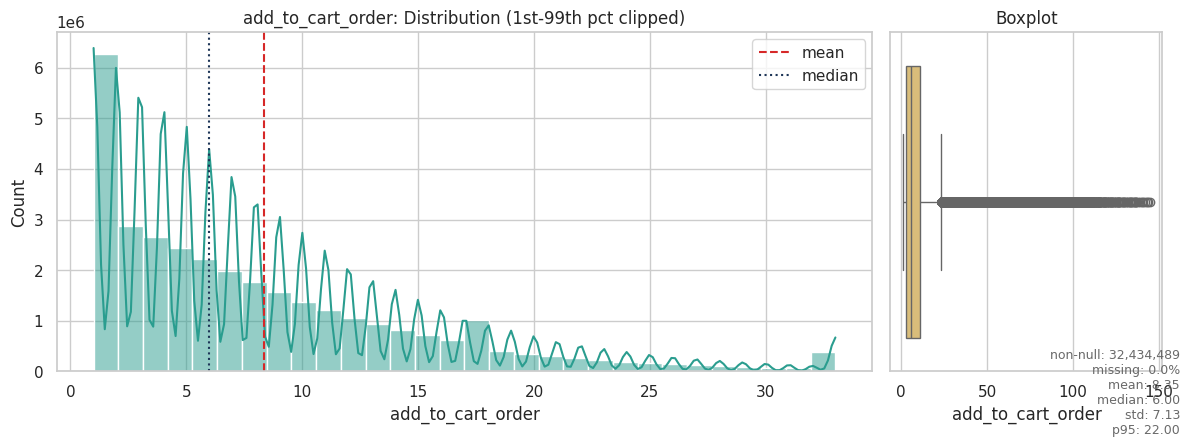

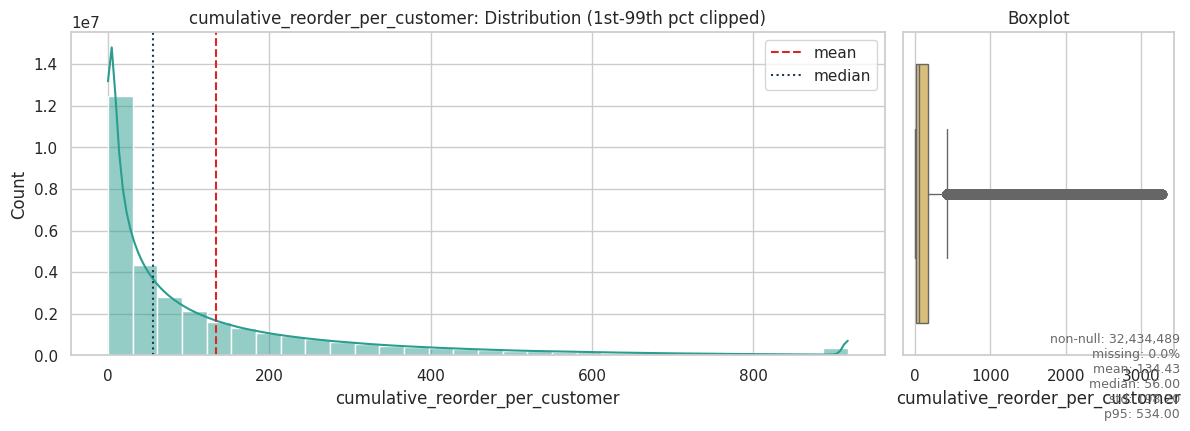

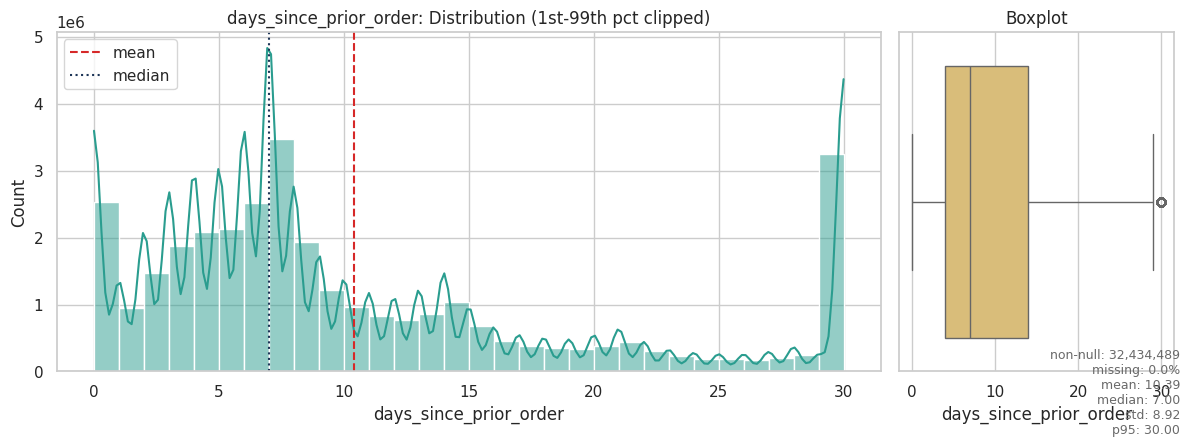

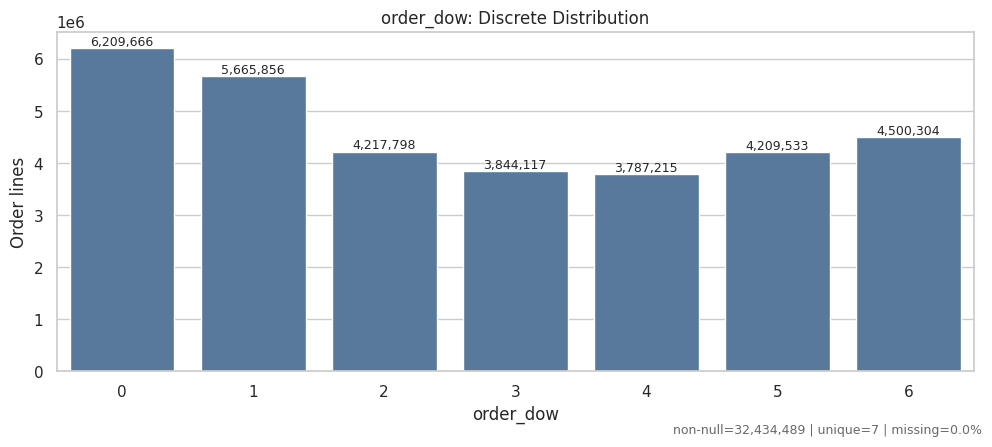

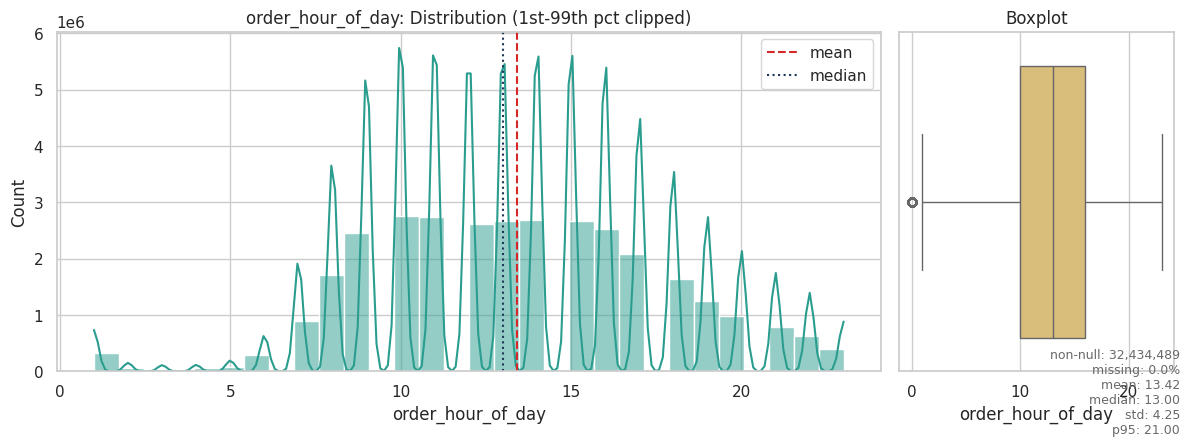

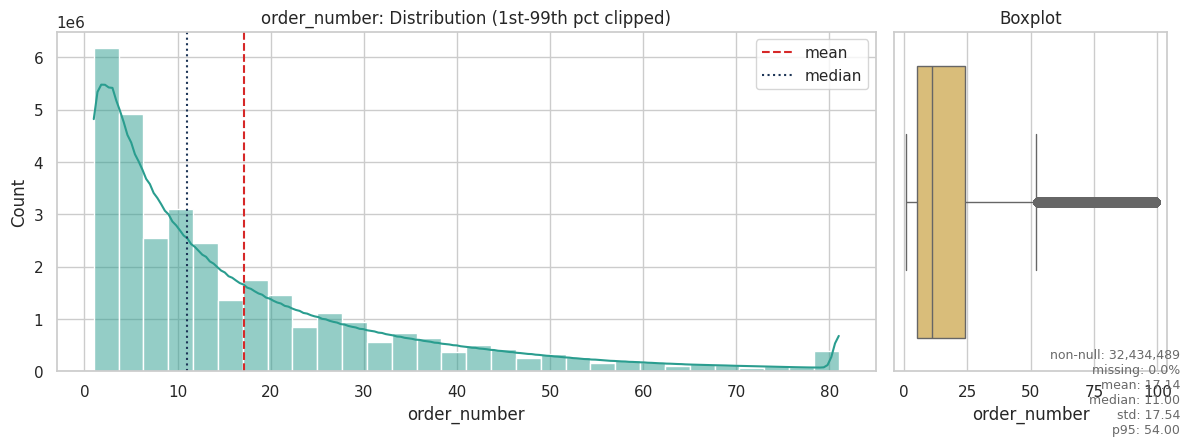

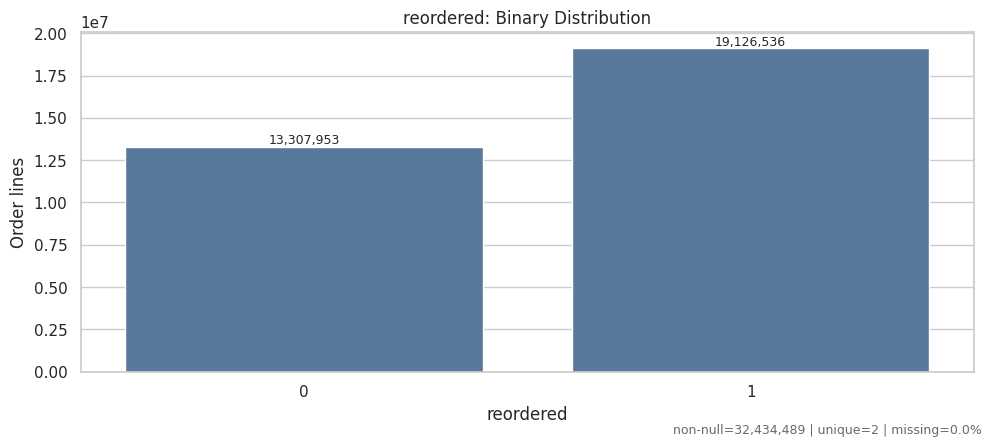

In [5]:
from pandas.api.types import is_bool_dtype, is_numeric_dtype, is_object_dtype, is_categorical_dtype
from IPython.display import display
import textwrap

TOP_N_CATEGORIES = 10

def classify_column(series: pd.Series) -> str | None:
    non_null = series.dropna()
    if non_null.empty:
        return None

    unique_vals = non_null.nunique()
    if unique_vals <= 1:
        return None

    if is_bool_dtype(series):
        return "binary"

    if is_object_dtype(series) or is_categorical_dtype(series):
        return "categorical"

    if is_numeric_dtype(series):
        if unique_vals <= 2:
            return "binary"
        if pd.api.types.is_integer_dtype(series) and unique_vals <= 20:
            return "discrete"
        return "continuous"

    return None


def add_count_labels(ax, total_count: int) -> None:
    for patch in ax.patches:
        width = patch.get_width()
        if width <= 0:
            continue
        percentage = width / total_count
        ax.text(
            width,
            patch.get_y() + patch.get_height() / 2,
            f"  {int(width):,} ({percentage:.1%})",
            va="center",
            ha="left",
            fontsize=9,
        )


profile_rows = []

for col in df.columns:
    series = df[col]
    non_null = series.dropna()
    missing_pct = series.isna().mean()
    unique_vals = non_null.nunique()
    unique_ratio = unique_vals / max(len(non_null), 1)

    if "id" in col.lower():
        profile_rows.append({
            "column": col,
            "status": "skipped",
            "reason": "identifier field",
            "non_null": len(non_null),
            "unique": unique_vals,
            "missing_pct": round(missing_pct * 100, 2),
        })
        continue

    plot_type = classify_column(series)
    if plot_type is None:
        profile_rows.append({
            "column": col,
            "status": "skipped",
            "reason": "constant or empty column",
            "non_null": len(non_null),
            "unique": unique_vals,
            "missing_pct": round(missing_pct * 100, 2),
        })
        continue

    if plot_type == "categorical" and unique_ratio > 0.5 and unique_vals > TOP_N_CATEGORIES:
        profile_rows.append({
            "column": col,
            "status": "skipped",
            "reason": "too many categories for overview view",
            "non_null": len(non_null),
            "unique": unique_vals,
            "missing_pct": round(missing_pct * 100, 2),
        })
        continue

    profile_rows.append({
        "column": col,
        "status": "plotted",
        "reason": plot_type,
        "non_null": len(non_null),
        "unique": unique_vals,
        "missing_pct": round(missing_pct * 100, 2),
    })

profile_summary = pd.DataFrame(profile_rows).sort_values(["status", "column"]).reset_index(drop=True)
display(profile_summary)

for row in profile_summary.itertuples(index=False):
    if row.status != "plotted":
        continue

    col = row.column
    series = df[col]
    non_null = series.dropna()
    missing_pct = series.isna().mean()
    plot_type = row.reason

    if plot_type == "categorical":
        value_counts = non_null.astype(str).value_counts()
        top_counts = value_counts.head(TOP_N_CATEGORIES).sort_values()
        coverage = top_counts.sum() / value_counts.sum()

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(
            x=top_counts.values,
            y=top_counts.index,
            orient="h",
            palette="crest",
            ax=ax,
        )
        add_count_labels(ax, len(non_null))
        ax.set_title(f"{col}: Top Categories")
        ax.set_xlabel("Order lines")
        ax.set_ylabel("Category")
        fig.text(
            0.99,
            0.01,
            f"non-null={len(non_null):,} | unique={row.unique:,} | missing={missing_pct:.1%} | top-{TOP_N_CATEGORIES} coverage={coverage:.1%}",
            ha="right",
            va="bottom",
            fontsize=9,
            color="dimgray",
        )
        plt.tight_layout()
        plt.show()

    elif plot_type in {"binary", "discrete"}:
        counts = non_null.value_counts().sort_index()
        fig, ax = plt.subplots(figsize=(10, 4.5))
        sns.barplot(x=counts.index.astype(str), y=counts.values, color="#4c78a8", ax=ax)
        ax.set_title(f"{col}: {plot_type.title()} Distribution")
        ax.set_xlabel(col)
        ax.set_ylabel("Order lines")
        for idx, count in enumerate(counts.values):
            ax.text(idx, count, f"{count:,}", ha="center", va="bottom", fontsize=9)
        fig.text(
            0.99,
            0.01,
            f"non-null={len(non_null):,} | unique={row.unique:,} | missing={missing_pct:.1%}",
            ha="right",
            va="bottom",
            fontsize=9,
            color="dimgray",
        )
        plt.tight_layout()
        plt.show()

    elif plot_type == "continuous":
        p01, p99 = non_null.quantile([0.01, 0.99])
        clipped = non_null.clip(lower=p01, upper=p99)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [3, 1]})
        sns.histplot(clipped, kde=True, bins=30, color="#2a9d8f", ax=axes[0])
        axes[0].axvline(non_null.mean(), color="#d62828", linestyle="--", linewidth=1.5, label="mean")
        axes[0].axvline(non_null.median(), color="#1d3557", linestyle=":", linewidth=1.5, label="median")
        axes[0].set_title(f"{col}: Distribution (1st-99th pct clipped)")
        axes[0].set_xlabel(col)
        axes[0].legend()

        sns.boxplot(x=non_null, color="#e9c46a", ax=axes[1])
        axes[1].set_title("Boxplot")
        axes[1].set_xlabel(col)

        summary_text = textwrap.dedent(
            f"""
            non-null: {len(non_null):,}
            missing: {missing_pct:.1%}
            mean: {non_null.mean():.2f}
            median: {non_null.median():.2f}
            std: {non_null.std():.2f}
            p95: {non_null.quantile(0.95):.2f}
            """
        ).strip()
        fig.text(0.99, 0.01, summary_text, ha="right", va="bottom", fontsize=9, color="dimgray")
        plt.tight_layout()
        plt.show()

### สรุป Insight
- ลูกค้า ส่วนใหญ่เพิามสินค้า ใน ordercart ไม่มาก มีค่าเฉลี่ย 5 ชิ้นต่อตะกร้าสินค้า

- 

## Next Step

Detailed customer-level bivariate analysis was moved to:
`notebooks/02_Exploratory_Data_Analysis/02_customer_behavior.ipynb`

This overview notebook now focuses on quick distribution scanning only.